<div style="float: right;">
  <a href="../de/bias_training.html" style="margin-left: 10px;">Deutsch</a>
  <a href="../en/bias_training.html">English</a>
</div>

# 11. Introducing and Training on Biased Data

Now we'll simulate what happens in real-world data collection when certain groups are underrepresented.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load and prepare data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
                'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
                'hours_per_week', 'native_country', 'income']
adult_data = pd.read_csv(url, names=column_names, skipinitialspace=True, na_values='?')
adult_data = adult_data.dropna()
adult_data['target'] = (adult_data['income'] == '>50K').astype(int)
adult_data['sex'] = (adult_data['sex'] == 'Male').astype(int)

categorical_cols = ['workclass', 'marital_status', 'occupation', 'relationship', 'race']
for col in categorical_cols:
    le = LabelEncoder()
    adult_data[col] = le.fit_transform(adult_data[col])

feature_cols = ['age', 'workclass', 'education_num', 'marital_status',
                'occupation', 'relationship', 'race', 'sex',
                'capital_gain', 'capital_loss', 'hours_per_week']
X = adult_data[feature_cols]
y = adult_data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=adult_data['sex']
)

print("Data loaded successfully!")

Data loaded successfully!


## Creating a Biased Training Set

We'll create a biased training set by **undersampling female individuals**. This mirrors real-world scenarios where:
- Workforce datasets have historically been dominated by male employees
- Hiring and promotion data may underrepresent women in certain industries
- Salary surveys may have lower response rates from particular demographics

In [2]:
def create_biased_sample(X, y, sex_col='sex', female_ratio=0.1):
    """
    Create a biased training sample by undersampling female individuals.

    Parameters:
    - female_ratio: proportion of female individuals to keep (0.1 = keep only 10%)
    """
    # Separate by sex
    female_mask = X[sex_col] == 0
    male_mask = X[sex_col] == 1

    X_female = X[female_mask]
    y_female = y[female_mask]
    X_male = X[male_mask]
    y_male = y[male_mask]

    # Undersample females
    n_female_keep = max(1, int(len(X_female) * female_ratio))
    female_indices = np.random.choice(len(X_female), n_female_keep, replace=False)

    X_female_sampled = X_female.iloc[female_indices]
    y_female_sampled = y_female.iloc[female_indices]

    # Combine
    X_biased = pd.concat([X_female_sampled, X_male])
    y_biased = pd.concat([y_female_sampled, y_male])

    return X_biased, y_biased

# Create biased training set (keep only 10% of females)
X_train_biased, y_train_biased = create_biased_sample(X_train, y_train, female_ratio=0.1)

print("Biased Training Set Statistics")
print("=" * 50)
print(f"Original training set size: {len(X_train)}")
print(f"Biased training set size: {len(X_train_biased)}")
print(f"\nOriginal sex distribution:")
print(f"  Female: {(X_train['sex'] == 0).sum()} ({100*(X_train['sex'] == 0).mean():.1f}%)")
print(f"  Male: {(X_train['sex'] == 1).sum()} ({100*(X_train['sex'] == 1).mean():.1f}%)")
print(f"\nBiased sex distribution:")
print(f"  Female: {(X_train_biased['sex'] == 0).sum()} ({100*(X_train_biased['sex'] == 0).mean():.1f}%)")
print(f"  Male: {(X_train_biased['sex'] == 1).sum()} ({100*(X_train_biased['sex'] == 1).mean():.1f}%)")

Biased Training Set Statistics
Original training set size: 21113
Biased training set size: 14950

Original sex distribution:
  Female: 6847 (32.4%)
  Male: 14266 (67.6%)

Biased sex distribution:
  Female: 684 (4.6%)
  Male: 14266 (95.4%)


## Visualizing the Demographic Shift

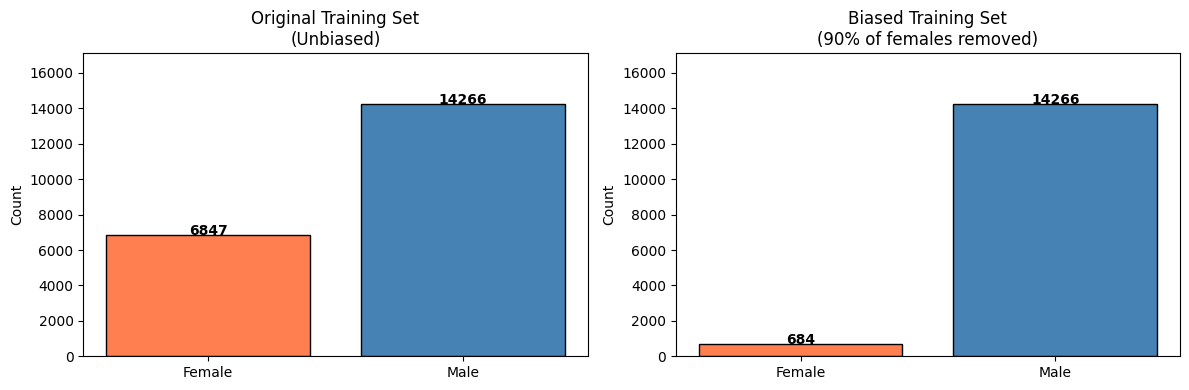

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original training distribution
original_counts = X_train['sex'].value_counts().sort_index()
axes[0].bar(['Female', 'Male'], [original_counts.get(0, 0), original_counts.get(1, 0)],
            color=['coral', 'steelblue'], edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Original Training Set\n(Unbiased)')
axes[0].set_ylim(0, max(original_counts) * 1.2)
for i, v in enumerate([original_counts.get(0, 0), original_counts.get(1, 0)]):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Biased training distribution
biased_counts = X_train_biased['sex'].value_counts().sort_index()
axes[1].bar(['Female', 'Male'], [biased_counts.get(0, 0), biased_counts.get(1, 0)],
            color=['coral', 'steelblue'], edgecolor='black')
axes[1].set_ylabel('Count')
axes[1].set_title('Biased Training Set\n(90% of females removed)')
axes[1].set_ylim(0, max(original_counts) * 1.2)
for i, v in enumerate([biased_counts.get(0, 0), biased_counts.get(1, 0)]):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Training Models on Biased Data

Now let's train the same models on our biased training data:

In [4]:
# Scale data
scaler = StandardScaler()
scaler.fit(X_train_biased)
X_train_biased_scaled = scaler.transform(X_train_biased)
X_test_scaled = scaler.transform(X_test)

# Also train baseline models for comparison
scaler_baseline = StandardScaler()
X_train_scaled = scaler_baseline.fit_transform(X_train)
X_test_scaled_baseline = scaler_baseline.transform(X_test)

# Baseline models
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr_baseline = lr_baseline.predict(X_test_scaled_baseline)

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_baseline.fit(X_train_scaled, y_train)
y_pred_rf_baseline = rf_baseline.predict(X_test_scaled_baseline)

# Biased models
lr_biased = LogisticRegression(random_state=42, max_iter=1000)
lr_biased.fit(X_train_biased_scaled, y_train_biased)
y_pred_lr_biased = lr_biased.predict(X_test_scaled)

rf_biased = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_biased.fit(X_train_biased_scaled, y_train_biased)
y_pred_rf_biased = rf_biased.predict(X_test_scaled)

print("Models trained on biased data!")

Models trained on biased data!


## Comparing Model Coefficients

Let's see how the sampling bias affected what the Logistic Regression model learned:

In [5]:
# Compare Logistic Regression coefficients
coef_comparison = pd.DataFrame({
    'Feature': feature_cols,
    'Baseline Coefficients': lr_baseline.coef_[0],
    'Biased Coefficients': lr_biased.coef_[0]
})
coef_comparison['Difference'] = coef_comparison['Biased Coefficients'] - coef_comparison['Baseline Coefficients']
coef_comparison = coef_comparison.sort_values('Difference', key=abs, ascending=False)

print("Logistic Regression Coefficient Comparison")
print("=" * 60)
print(coef_comparison.to_string(index=False))

Logistic Regression Coefficient Comparison
       Feature  Baseline Coefficients  Biased Coefficients  Difference
  relationship              -0.179954            -0.840618   -0.660664
           sex               0.461154             0.032060   -0.429093
  capital_gain               2.361543             2.500403    0.138860
marital_status              -0.340979            -0.261430    0.079549
           age               0.471447             0.405315   -0.066132
     workclass              -0.125846            -0.163021   -0.037175
 education_num               0.861804             0.884838    0.023034
          race               0.086131             0.066040   -0.020091
    occupation               0.008365             0.022833    0.014467
hours_per_week               0.333422             0.340720    0.007299
  capital_loss               0.276283             0.280818    0.004535


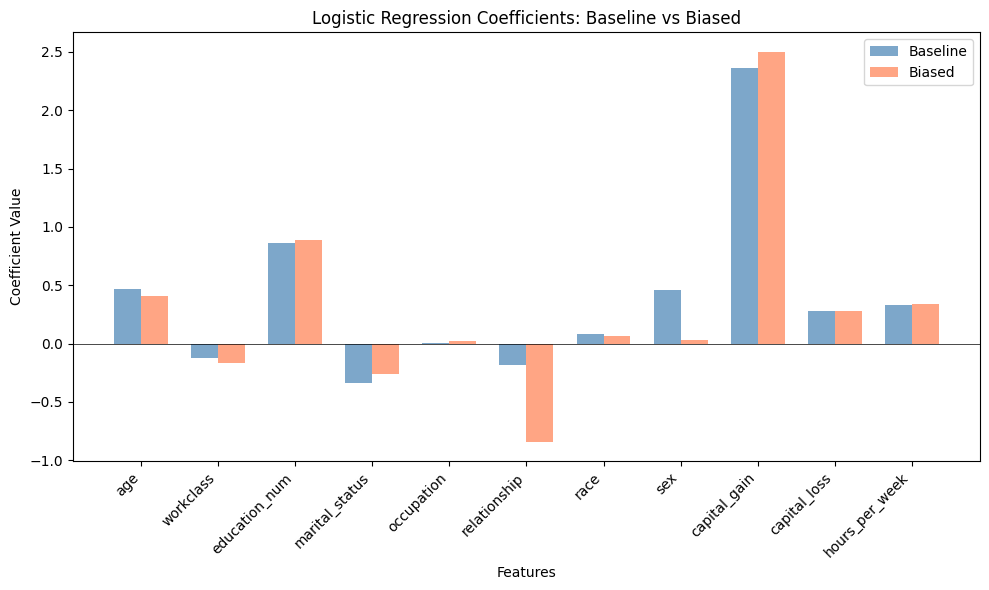

In [6]:
# Visualize coefficient changes
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(feature_cols))
width = 0.35
ax.bar([i - width/2 for i in x], lr_baseline.coef_[0], width, label='Baseline', color='steelblue', alpha=0.7)
ax.bar([i + width/2 for i in x], lr_biased.coef_[0], width, label='Biased', color='coral', alpha=0.7)
ax.set_xlabel('Features')
ax.set_ylabel('Coefficient Value')
ax.set_title('Logistic Regression Coefficients: Baseline vs Biased')
ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## Comparing Feature Importance (Random Forest)

In [7]:
# Compare Random Forest feature importances
importance_comparison = pd.DataFrame({
    'Feature': feature_cols,
    'Baseline Importance': rf_baseline.feature_importances_,
    'Biased Importance': rf_biased.feature_importances_
})
importance_comparison['Difference'] = importance_comparison['Biased Importance'] - importance_comparison['Baseline Importance']
importance_comparison = importance_comparison.sort_values('Baseline Importance', ascending=False)

print("Random Forest Feature Importance Comparison")
print("=" * 60)
print(importance_comparison.to_string(index=False))

Random Forest Feature Importance Comparison
       Feature  Baseline Importance  Biased Importance  Difference
  capital_gain             0.248289           0.237157   -0.011133
  relationship             0.215051           0.177043   -0.038009
marital_status             0.183948           0.162443   -0.021505
 education_num             0.182811           0.236490    0.053678
           age             0.058795           0.070576    0.011781
  capital_loss             0.037521           0.052947    0.015426
hours_per_week             0.030889           0.036252    0.005363
           sex             0.023587           0.001220   -0.022367
    occupation             0.016875           0.022616    0.005741
     workclass             0.001718           0.002853    0.001135
          race             0.000514           0.000403   -0.000111


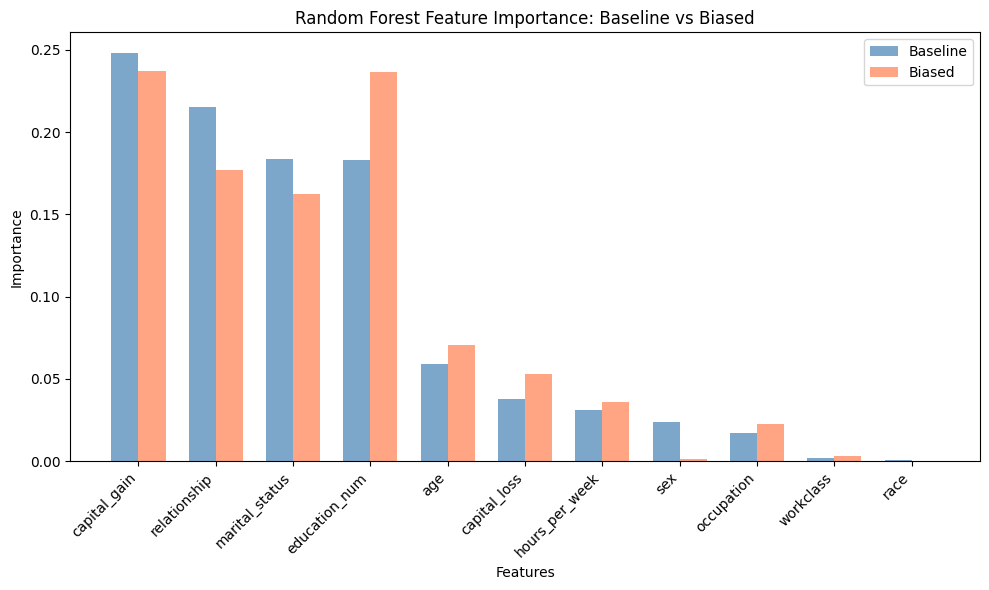

In [8]:
# Visualize importance changes
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(feature_cols))
width = 0.35
sorted_features = importance_comparison['Feature'].tolist()
ax.bar([i - width/2 for i in x], importance_comparison['Baseline Importance'], width,
       label='Baseline', color='steelblue', alpha=0.7)
ax.bar([i + width/2 for i in x], importance_comparison['Biased Importance'], width,
       label='Biased', color='coral', alpha=0.7)
ax.set_xlabel('Features')
ax.set_ylabel('Importance')
ax.set_title('Random Forest Feature Importance: Baseline vs Biased')
ax.set_xticks(x)
ax.set_xticklabels(sorted_features, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Key Observations

Notice how the biased training data affects:
1. **Coefficient values** - The model learns different relationships between features and outcomes
2. **Feature importance** - The relative importance of features shifts when trained on biased data
3. **The sex coefficient** - Pay attention to how the coefficient for 'sex' changes between models

In the next section, we'll evaluate how these changes impact model performance across demographic groups.